In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
os.getcwd()

'C:\\Users\\golde\\PycharmProjects\\pred_main_project_brueggen\\timeline_maschine_failure'

In [19]:
df = pd.read_csv(
    "../data/processed/aufschreibung_hra_clean.csv",
    sep=","
)

print("Data loaded successfully")
df.head()

Data loaded successfully


,Datum,Wochentag,DatumNEU,KW,Schicht,Zeit von,Zeit bis,Dauer Arbeits-zeit,Anzahl MA,Menge N.i. O.,...,Station/ OP_raw,Station/ OP_1,Station/ OP_2,Station/ OP_3,Station/ OP_4,Station/ OP_5,Bemerkung_norm,Bemerkung_std,Unterbrechungsursache_norm,Unterbrechungsursache_std
0,2023-01-05,4.0,2023-01-05 00:00:00,2023/01,t,07:00:00,08:00:00,60.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,gestelle anmelden,gestelle anmelden,freitext,freitext
1,2023-01-05,4.0,2023-01-05 00:00:00,2023/01,t,07:00:00,08:00:00,60.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wartungsplan,wartungsplan
2,2023-01-05,4.0,2023-01-05 00:00:00,2023/01,t,07:00:00,08:00:00,60.0,2.0,NaN,...,R 03,R 03,NaN,NaN,NaN,NaN,"programmfehler, greifer defekt, räumen","programmfehler, greifer defekt, räumen",freitext,freitext
3,2023-01-05,4.0,2023-01-05 00:00:00,2023/01,t,08:00:00,09:00:00,60.0,2.0,NaN,...,R 03,R 03,NaN,NaN,NaN,NaN,"programmfehler, greifer defekt, räumen","programmfehler, greifer defekt, räumen",freitext,freitext
4,2023-01-05,4.0,2023-01-05 00:00:00,2023/01,t,09:15:00,10:00:00,45.0,2.0,NaN,...,R 03,R 03,NaN,NaN,NaN,NaN,"programmfehler, greifer defekt, räumen","programmfehler, greifer defekt, räumen",freitext,freitext


In [47]:
# --------------------------------------------
# 2) Define Columns
# --------------------------------------------
machine_col = "Station/ OP"
unterbrechung_col = "Unterbrechungsursache"
bemerkung_col = "Bemerkung"
dauer_spalten = [
    "Dauer Anlagen-Ausfall",
    "Dauer Anlagen-Ausfall intern",
    "Dauer Org-Mangel",
    "Dauer Logistik- Defizite",
    "Störung aufgrund Vormaterial"
]

# --------------------------------------------
# 3) Convert Dauer Columns to Numeric (Minutes)
# --------------------------------------------
for col in dauer_spalten:
    df[col] = (
        df[col].astype(str)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [46]:
# Maschine definieren
machine_col = "Station/ OP"

# Define Columns
ausfall_spalten = [
    "Dauer Anlagen-Ausfall",
    "Dauer Anlagen-Ausfall intern",
    "Dauer Org-Mangel",
    "Dauer Logistik- Defizite",
    "Störung aufgrund Vormaterial"
]
#Convert Failure Columns to Numeric
for col in ausfall_spalten:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")
#    Create Failure Flags (1 = Failure, 0 = No Failure)
for col in ausfall_spalten:
    df[col + "_flag"] = df[col].fillna(0).gt(0).astype(int)

# Overall failure (if any failure type occurred)
df["Gesamt_Ausfall"] = df[[col + "_flag" for col in ausfall_spalten]].max(axis=1)

# Count Failure Hours per Machine
ausfaelle_je_maschine = df.groupby(machine_col)["Gesamt_Ausfall"].sum()

ausfaelle_je_maschine.sort_values(ascending=False)



Station/ OP
OP 100 R          743
R 06              572
R 07              500
R 09              450
R 02              347
                 ... 
R 07 R 09           1
R 09+R 08           1
R 07+R 09           1
OP 90 OP 100 r      0
R 06 + R 09         0
Name: Gesamt_Ausfall, Length: 75, dtype: int64

In [ ]:
df["Timestamp"] = pd.to_datetime(df["Datum"] + " " + df["Zeit von"], errors="coerce")
df = df.sort_values("Timestamp")


# --------------------------------------------
# 8) Create Running Status (1 = Running, 0 = Failure)
# --------------------------------------------
df["Status"] = (df["Gesamt_Ausfall"] == 0).astype(int)


# --------------------------------------------
# 9) Timeline per Machine (State Visualization - no connecting lines)
# --------------------------------------------
import matplotlib.dates as mdates

maschinen = df[machine_col].dropna().unique()

for maschine in maschinen:
    subset = df[df[machine_col] == maschine].copy()
    subset = subset.sort_values("Timestamp")
    
    plt.figure()
    
    # Step plot for state visualization (no diagonal transitions)
    plt.step(subset["Timestamp"], subset["Status"], where="post")
    
    plt.title(f"Timeline Machine {maschine}")
    plt.xlabel("Time")
    plt.ylabel("Status (1=Running, 0=Failure)")
    
    # Finer x-axis formatting
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
failure_events = []

for maschine in maschinen:
    subset = df[df[machine_col] == maschine].copy()
    subset = subset.sort_values("Timestamp")
    
    subset["prev_status"] = subset["Status"].shift(1)
    subset["new_failure_event"] = (
        (subset["Status"] == 0) &
        (subset["prev_status"] == 1)
    ).astype(int)
    
    event_count = subset["new_failure_event"].sum()
    failure_events.append((maschine, event_count))

failure_events_df = pd.DataFrame(
    failure_events,
    columns=["Machine", "Failure_Events"]
).sort_values("Failure_Events", ascending=False)

print("True failure events per machine:")
print(failure_events_df)


# --------------------------------------------
# 11) Timeline per Machine and per Failure Type (State Visualization)
# --------------------------------------------
for maschine in maschinen:
    subset = df[df[machine_col] == maschine].copy()
    subset = subset.sort_values("Timestamp")
    
    for col in ausfall_spalten:
        status_col = col + "_flag"
        run_col = status_col + "_run"
        
        subset[run_col] = (subset[status_col] == 0).astype(int)
        
        plt.figure()
        plt.step(subset["Timestamp"], subset[run_col], where="post")
        
        plt.title(f"{maschine} – {col}")
        plt.xlabel("Time")
        plt.ylabel("Status (1=Running, 0=Failure)")
        
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


In [45]:
# --------------------------------------------
# 4) Create Timestamp
# --------------------------------------------
df["Timestamp"] = pd.to_datetime(df["Datum"] + " " + df["Zeit von"], errors="coerce")
df = df.sort_values("Timestamp")

# --------------------------------------------
# 5) Weekly Subset
# --------------------------------------------
week_start = pd.to_datetime("2023-01-02")
week_end = week_start + pd.Timedelta(days=7)
df_week = df[(df["Timestamp"] >= week_start) & (df["Timestamp"] < week_end)].copy()

# --------------------------------------------
# 6) Create DataFrame with All Anlagen Failures for the Week
# --------------------------------------------
maschinen = df_week[machine_col].dropna().unique()
weekly_failures_list = []

for maschine in maschinen:
    subset = df_week[df_week[machine_col] == maschine].copy()
    subset = subset.sort_values("Timestamp")
    if subset.empty:
        continue

    for col in ausfall_spalten:
        ausfall_subset = subset[subset[col] > 0][["Timestamp", col]].copy()
        ausfall_subset = ausfall_subset.rename(columns={col: "Dauer (Min)"})
        ausfall_subset["Ursache"] = col
        ausfall_subset["Maschine"] = maschine
        weekly_failures_list.append(ausfall_subset)

# Combined DataFrame for the week
df_weekly_anlagen_failures = pd.concat(weekly_failures_list, axis=0).sort_values("Timestamp").reset_index(drop=True)

print("Weekly Anlagen Failures DataFrame:")
display(df_weekly_anlagen_failures)

Weekly Anlagen Failures DataFrame:


,Timestamp,Dauer (Min),Ursache,Maschine
0,2023-01-05 07:00:00,5.0,Dauer Anlagen-Ausfall,R 03
1,2023-01-05 08:00:00,60.0,Dauer Anlagen-Ausfall,R 03
2,2023-01-05 09:15:00,45.0,Dauer Anlagen-Ausfall,R 03
3,2023-01-05 10:00:00,15.0,Dauer Anlagen-Ausfall,R 03
4,2023-01-05 10:00:00,30.0,Dauer Anlagen-Ausfall,R 06
5,2023-01-05 11:00:00,5.0,Dauer Anlagen-Ausfall,R 07
6,2023-01-05 11:00:00,10.0,Dauer Anlagen-Ausfall,R 02
7,2023-01-05 14:00:00,12.0,Dauer Anlagen-Ausfall,R 01
8,2023-01-05 14:00:00,10.0,Dauer Anlagen-Ausfall,R 02
9,2023-01-05 14:00:00,5.0,Dauer Anlagen-Ausfall,R 09


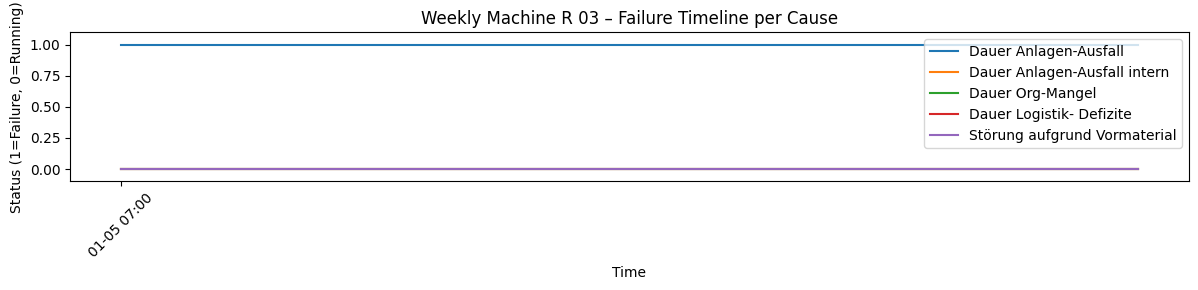

,Timestamp,Dauer (Min),Ursache,Maschine
0,2023-01-08 01:30:00,5.0,Dauer Anlagen-Ausfall,R 08


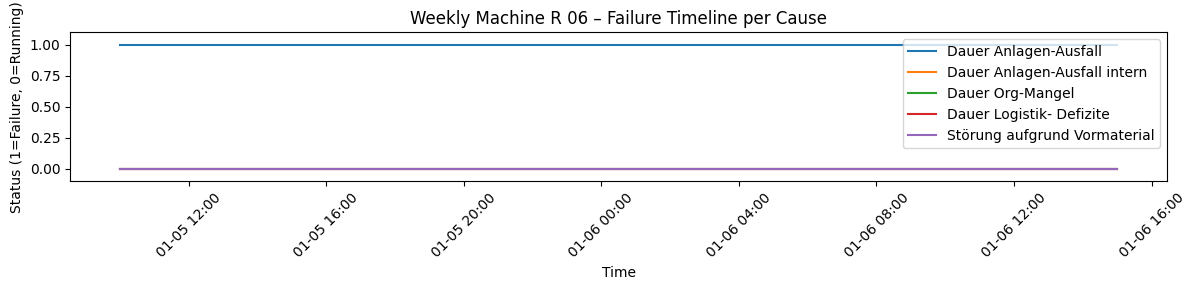

,Timestamp,Dauer (Min),Ursache,Maschine
0,2023-01-08 01:30:00,5.0,Dauer Anlagen-Ausfall,R 08


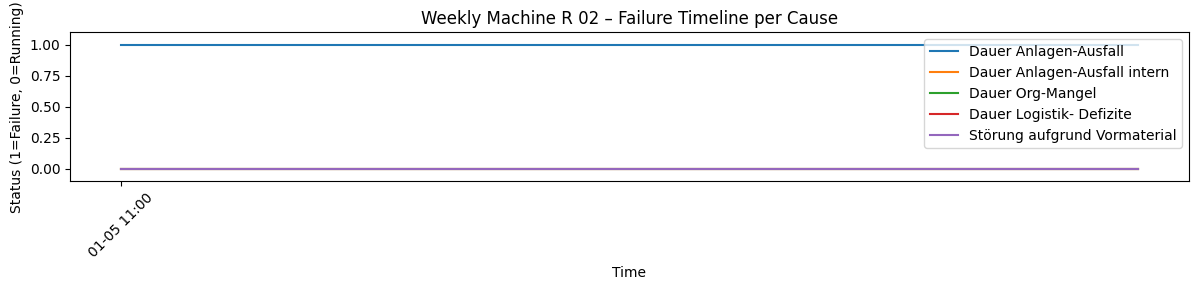

,Timestamp,Dauer (Min),Ursache,Maschine
0,2023-01-08 01:30:00,5.0,Dauer Anlagen-Ausfall,R 08


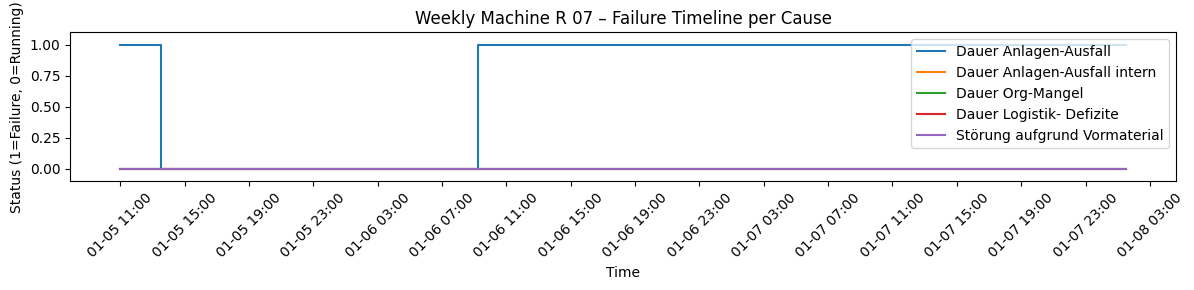

,Timestamp,Dauer (Min),Ursache,Maschine
0,2023-01-08 01:30:00,5.0,Dauer Anlagen-Ausfall,R 08


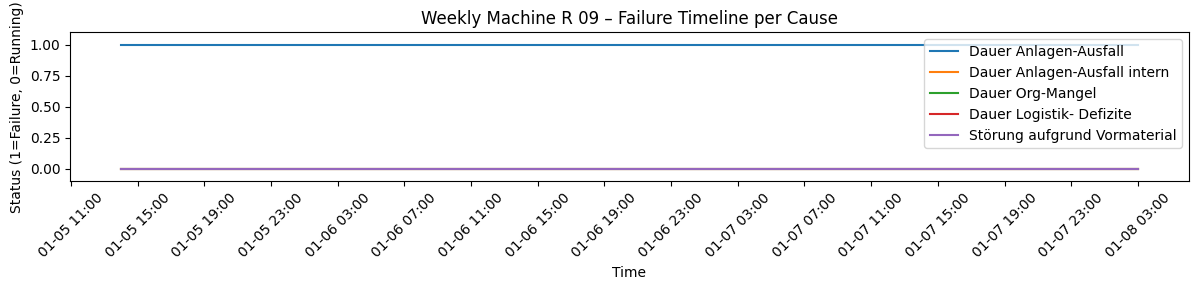

,Timestamp,Dauer (Min),Ursache,Maschine
0,2023-01-08 01:30:00,5.0,Dauer Anlagen-Ausfall,R 08


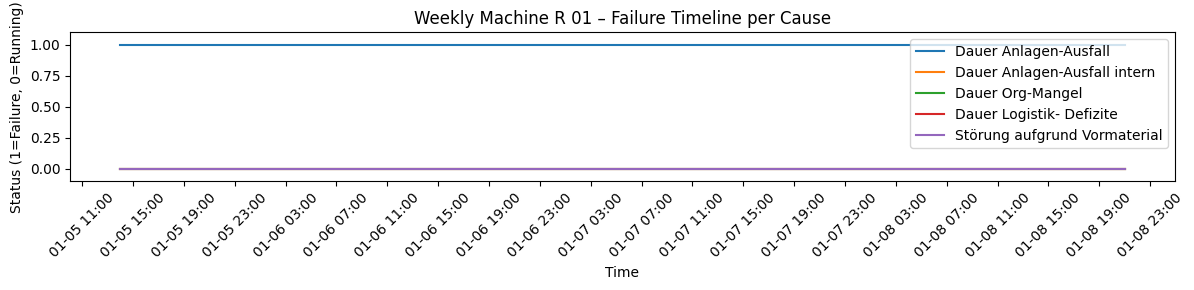

,Timestamp,Dauer (Min),Ursache,Maschine
0,2023-01-08 01:30:00,5.0,Dauer Anlagen-Ausfall,R 08


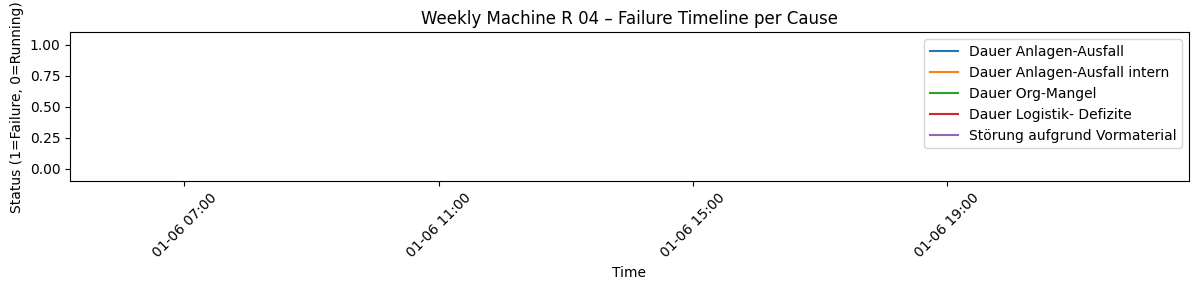

,Timestamp,Dauer (Min),Ursache,Maschine
0,2023-01-08 01:30:00,5.0,Dauer Anlagen-Ausfall,R 08


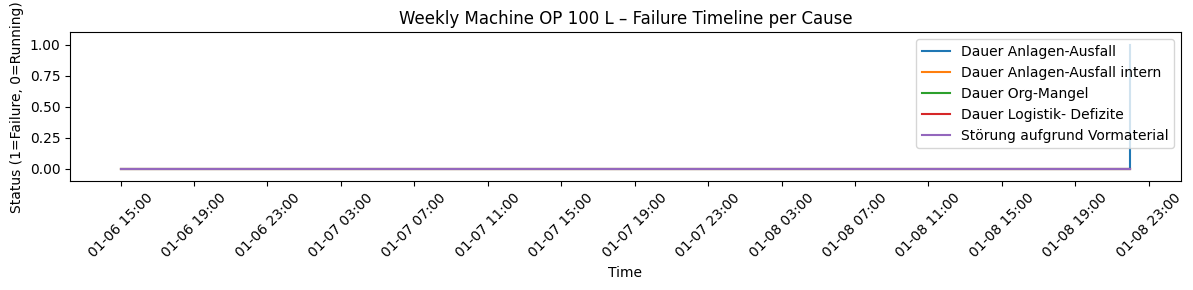

,Timestamp,Dauer (Min),Ursache,Maschine
0,2023-01-08 01:30:00,5.0,Dauer Anlagen-Ausfall,R 08


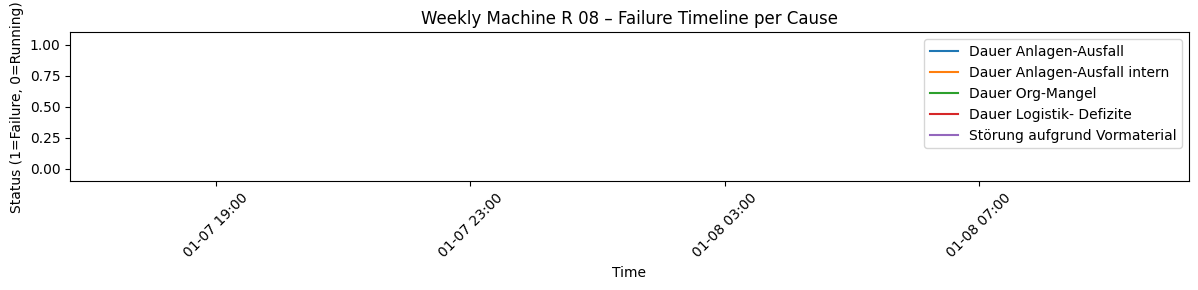

,Timestamp,Dauer (Min),Ursache,Maschine
0,2023-01-08 01:30:00,5.0,Dauer Anlagen-Ausfall,R 08


In [44]:
# --------------------------------------------
# 4) Create Timestamp
# --------------------------------------------
df["Timestamp"] = pd.to_datetime(df["Datum"] + " " + df["Zeit von"], errors="coerce")
df = df.sort_values("Timestamp")

# --------------------------------------------
# 5) Weekly Subset
# --------------------------------------------
week_start = pd.to_datetime("2023-01-02")
week_end = week_start + pd.Timedelta(days=7)
df_week = df[(df["Timestamp"] >= week_start) & (df["Timestamp"] < week_end)].copy()

maschinen = df_week[machine_col].dropna().unique()

# --------------------------------------------
# 6) Plot Timeline per Machine and per Cause with DF below (Duration in Minutes)
# --------------------------------------------
for maschine in maschinen:
    subset = df_week[df_week[machine_col] == maschine].copy()
    subset = subset.sort_values("Timestamp")
    if subset.empty:
        continue

    plt.figure(figsize=(12, 3))
    
    # Plot each failure cause separately using step plot
    for col in ausfall_spalten:
        status_col = col + "_flag"
        subset[status_col] = (subset[col] > 0).astype(int)
        # nur Punkte plotten, keine Verbindungslinien zwischen 0 und 1
        plt.step(subset["Timestamp"], subset[status_col], where="post", label=col)
    
    plt.title(f"Weekly Machine {maschine} – Failure Timeline per Cause")
    plt.xlabel("Time")
    plt.ylabel("Status (1=Failure, 0=Running)")
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    plt.xticks(rotation=45)
    plt.ylim(-0.1, 1.1)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    # --------------------------------------------
    # Corresponding DataFrame per Cause with Duration in Minutes
    # --------------------------------------------
    failure_rows = []
    for col in ausfall_spalten:
        ausfall_subset = subset[subset[col] > 0][["Timestamp", col]].copy()
        ausfall_subset = ausfall_subset.rename(columns={col: "Dauer (Min)"})
        ausfall_subset["Ursache"] = col
        ausfall_subset["Maschine"] = maschine
    display(maschine_failures_df)